# 10 - MobileNetV2 + Transformer Temporal Baseline
## Tai Phake Visual Speech Recognition (VSR) Project

**Target Architecture**: Pretrained **MobileNetV2** CNN frame feature extractor with a **Transformer Encoder** sequence head.

---
### Experimental Context & Scientific Objective
- **Baseline Comparison**: Directly compare this Transformer temporal head against the existing **MobileNetV2 + BiLSTM** baseline under strictly identical conditions.
- **Dataset Multiplication**: The training set utilizes multiplied/repeated training folders (e.g., 24 real training speakers $\rightarrow$ 100 training folders).
  > **Note**: These 100 folders represent 24 real training speakers with multiplied copies; speaker count remains 24.
- **Unseen Validation & Test Sets**:
  - **Validation**: `s1`, `s4`, `s21` (3 clean speakers, zero overlap with train)
  - **Test**: `s8`, `s9`, `s24` (3 clean speakers, zero overlap with train/val)
- **Input Specifications**: Method D letterboxed lip crops ($96 \times 96 \times 3$, RGB), standardized to exactly 30 frames per utterance.
- **Model Pipeline**:
  $$\text{Input } (30, 96, 96, 3) \rightarrow \text{MobileNetV2} \rightarrow (30, 1280) \rightarrow \text{Dense}(256) \rightarrow \text{LayerNorm} \rightarrow \text{Positional Encoding}$$
  $$\rightarrow \text{Transformer Block } \times 2 \rightarrow \text{GlobalAveragePooling1D} \rightarrow \text{Dropout}(0.4) \rightarrow \text{Dense}(11, \text{softmax})$$
- **Training Strategy**:
  - **Stage 1**: Frozen MobileNetV2, Adam (lr=1e-4), max 40 epochs, EarlyStopping (patience=8, monitor=val_loss).
  - **Stage 2**: Fine-tune top 20% MobileNetV2 (BatchNorm frozen), Adam (lr=1e-5), max 25 epochs, EarlyStopping (patience=6, monitor=val_loss).

## 2. Imports & Dependency Verification

In [25]:
# Section 2: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sklearn.metrics as metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
import keras

print(f"Python Version:     {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")

Python Version:     3.12.13
TensorFlow Version: 2.21.0
Keras Version:      3.15.1


## 3. Configuration & Hyperparameters

In [26]:
# Section 3: Configuration & Hyperparameters
SEED = 42

# Sequence & Image Specifications
NUM_CLASSES = 11
NUM_FRAMES = 30
FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3
BATCH_SIZE = 16

# Transformer Architecture Hyperparameters
EMBED_DIM = 256
NUM_HEADS = 4
KEY_DIM = 64          # 4 heads * 64 key_dim = 256
FFN_DIM = 512
NUM_TRANSFORMER_BLOCKS = 2
TRANSFORMER_DROPOUT = 0.2
HEAD_DROPOUT = 0.4

# Two-Stage Training Hyperparameters
STAGE1_LR = 1e-4
STAGE1_MAX_EPOCHS = 40
STAGE1_PATIENCE = 8

STAGE2_LR = 1e-5
STAGE2_MAX_EPOCHS = 25
STAGE2_PATIENCE = 6
FINE_TUNE_FRACTION = 0.20

# Class labels
DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print(f"Digit Classes ({len(DIGIT_CLASSES)}): {DIGIT_CLASSES}")
print(f"Transformer Configuration: embed_dim={EMBED_DIM}, heads={NUM_HEADS}, key_dim={KEY_DIM}, ffn_dim={FFN_DIM}, blocks={NUM_TRANSFORMER_BLOCKS}")
print(f"Training Protocol: Stage 1 (lr={STAGE1_LR}, max_epochs={STAGE1_MAX_EPOCHS}), Stage 2 (lr={STAGE2_LR}, max_epochs={STAGE2_MAX_EPOCHS})")

Digit Classes (11): ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10']
Transformer Configuration: embed_dim=256, heads=4, key_dim=64, ffn_dim=512, blocks=2
Training Protocol: Stage 1 (lr=0.0001, max_epochs=40), Stage 2 (lr=1e-05, max_epochs=25)


## 4. Reproducibility Setup
Deterministic seeding across Python, NumPy, and TensorFlow.

In [27]:
# Section 4: Reproducibility Seeding
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Reproducibility seed locked to: {SEED}")

Reproducibility seed locked to: 42


## 5. Dataset Paths & Output Directories
Configure `DATA_DIR` to point to the active dataset partition folder.
By default, this points to `data/processed` (switched via `scripts/switch_dataset.py`).

In [28]:
# Section 5: Dataset Paths Configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# ==============================================================================
# DATASET PATH CONFIGURATION
# Set DATA_DIR to your active dataset directory containing train, val, test splits.
# To switch active dataset via CLI: python3 scripts/switch_dataset.py [DATASET_NAME]
# ==============================================================================
DATA_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# Dedicated Results Directory (prevents overwriting BiLSTM baseline artifacts)
RESULTS_DIR = PROJECT_ROOT / "results" / "transformer_baseline"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root:      {PROJECT_ROOT}")
print(f"Dataset Directory: {DATA_DIR}")
print(f"Train Directory:   {TRAIN_DIR}")
print(f"Val Directory:     {VAL_DIR}")
print(f"Test Directory:    {TEST_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Project Root:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Dataset Directory: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed
Train Directory:   /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/train
Val Directory:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/val
Test Directory:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/test
Results Directory: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline


## 6. Speaker Split Discovery & Multiplied Folder Recognition
We index speaker subdirectories in `train/`, `val/`, and `test/`.
Multiplied/repeated folders (e.g. `s2_dup1`, `s2_dup2`) map back to their base identity `s2`.

In [29]:
# Section 6: Speaker Discovery & Split Accounting
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
val_speakers = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
test_speakers = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])

# Extract canonical base speaker IDs (e.g. 's2_dup1' or 's2_aug1' -> 's2')
def get_base_speaker(spk_name: str) -> str:
    return spk_name.split("_")[0]

base_train_speakers = sorted(
    list({get_base_speaker(s) for s in train_speakers}),
    key=lambda x: int(re.search(r'\d+', x).group(0)) if re.search(r'\d+', x) else x
)

print("=" * 80)
print("                     SPEAKER PARTITION SUMMARY")
print("=" * 80)
print(f"Train Folders Discovered : {len(train_speakers)}")
print(f"Base Train Speakers      : {len(base_train_speakers)} ({base_train_speakers})")
print(f"Validation Speakers      : {len(val_speakers)} ({val_speakers})")
print(f"Test Speakers            : {len(test_speakers)} ({test_speakers})")
print("-" * 80)
print(f">> NOTE: {len(train_speakers)} training folders represent {len(base_train_speakers)} real training speakers with multiplied copies; speaker count remains {len(base_train_speakers)}.")
print("=" * 80)

# Save speaker partition metadata
split_metadata = {
    "random_seed": SEED,
    "num_train_folders": len(train_speakers),
    "num_base_train_speakers": len(base_train_speakers),
    "num_val_speakers": len(val_speakers),
    "num_test_speakers": len(test_speakers),
    "base_train_speakers": base_train_speakers,
    "train_speakers": train_speakers,
    "val_speakers": val_speakers,
    "test_speakers": test_speakers,
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(split_metadata, f, indent=2)

                     SPEAKER PARTITION SUMMARY
Train Folders Discovered : 120
Base Train Speakers      : 24 (['s2', 's3', 's5', 's6', 's7', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's22', 's23', 's25', 's26', 's27', 's28', 's29', 's30'])
Validation Speakers      : 3 (['s1', 's21', 's4'])
Test Speakers            : 3 (['s24', 's8', 's9'])
--------------------------------------------------------------------------------
>> NOTE: 120 training folders represent 24 real training speakers with multiplied copies; speaker count remains 24.


## 7. Strict Data Leakage Assertions
Verifies that:
1. Train and validation have no speaker overlap
2. Train and test have no speaker overlap
3. Validation and test have no speaker overlap
4. Validation contains no augmented/multiplied variants
5. Test contains no augmented/multiplied variants
6. Validation contains only the 3 canonical speakers (`s1`, `s4`, `s21`)
7. Test contains only the 3 canonical speakers (`s8`, `s9`, `s24`)

In [30]:
# Section 7: Strict Zero-Leakage Verification
EXPECTED_VAL_SPEAKERS = {"s1", "s4", "s21"}
EXPECTED_TEST_SPEAKERS = {"s8", "s9", "s24"}

set_base_train = set(base_train_speakers)
set_val = set(val_speakers)
set_test = set(test_speakers)

# 1. Zero overlap between Train and Validation
assert len(set_base_train & set_val) == 0, f"DATA LEAKAGE: Overlap between Train and Validation: {set_base_train & set_val}"

# 2. Zero overlap between Train and Test
assert len(set_base_train & set_test) == 0, f"DATA LEAKAGE: Overlap between Train and Test: {set_base_train & set_test}"

# 3. Zero overlap between Validation and Test
assert len(set_val & set_test) == 0, f"DATA LEAKAGE: Overlap between Validation and Test: {set_val & set_test}"

# 4. Validation contains no multiplied/augmented folders
for s in val_speakers:
    assert "_" not in s, f"DATA LEAKAGE: Multiplied folder '{s}' found in validation partition!"

# 5. Test contains no multiplied/augmented folders
for s in test_speakers:
    assert "_" not in s, f"DATA LEAKAGE: Multiplied folder '{s}' found in test partition!"

# 6. Validation contains only the 3 canonical validation speakers
assert set_val == EXPECTED_VAL_SPEAKERS, f"Validation speakers mismatch! Expected {EXPECTED_VAL_SPEAKERS}, found {set_val}"

# 7. Test contains only the 3 canonical test speakers
assert set_test == EXPECTED_TEST_SPEAKERS, f"Test speakers mismatch! Expected {EXPECTED_TEST_SPEAKERS}, found {set_test}"

print("=" * 80)
print("               ALL 7 DATA LEAKAGE ASSERTIONS PASSED")
print("=" * 80)
print("  [x] Train & Val: Zero overlap")
print("  [x] Train & Test: Zero overlap")
print("  [x] Val & Test: Zero overlap")
print("  [x] Val Partition: Clean original speakers only")
print("  [x] Test Partition: Clean original speakers only")
print("  [x] Canonical Val Set: {'s1', 's4', 's21'}")
print("  [x] Canonical Test Set: {'s8', 's9', 's24'}")
print("=" * 80)

               ALL 7 DATA LEAKAGE ASSERTIONS PASSED
  [x] Train & Val: Zero overlap
  [x] Train & Test: Zero overlap
  [x] Val & Test: Zero overlap
  [x] Val Partition: Clean original speakers only
  [x] Test Partition: Clean original speakers only
  [x] Canonical Val Set: {'s1', 's4', 's21'}
  [x] Canonical Test Set: {'s8', 's9', 's24'}


## 8. Utterance Manifest Creation
Index all available video utterance sequences across train, val, and test splits.

In [31]:
# Section 8: Utterance Indexing & Manifest Assembly
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

split_dirs = {"train": TRAIN_DIR, "val": VAL_DIR, "test": TEST_DIR}
utterances = []

for split_name, s_dir in split_dirs.items():
    spk_dirs = sorted([d for d in s_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    for s_path in spk_dirs:
        spk = s_path.name
        base_spk = get_base_speaker(spk)
        for digit in DIGIT_CLASSES:
            digit_dir = s_path / digit
            if not digit_dir.exists():
                continue
            frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
            if len(frames) == 0:
                continue
            utterances.append({
                "speaker": spk,
                "base_speaker": base_spk,
                "digit": digit,
                "digit_id": CLASS_TO_ID[digit],
                "split": split_name,
                "raw_frame_count": len(frames),
                "frame_paths": frames
            })

df_manifest = pd.DataFrame(utterances)

print(f"Total Utterances Indexed: {len(df_manifest):,}")
print(f"  Train : {len(df_manifest[df_manifest['split']=='train']):,} utterances ({len(train_speakers)} folders, {len(base_train_speakers)} base speakers)")
print(f"  Val   : {len(df_manifest[df_manifest['split']=='val']):,} utterances ({len(val_speakers)} speakers)")
print(f"  Test  : {len(df_manifest[df_manifest['split']=='test']):,} utterances ({len(test_speakers)} speakers)")

# Save manifest to CSV
df_manifest[["speaker", "base_speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    RESULTS_DIR / "utterance_manifest.csv", index=False
)
print(f"Manifest saved to: {RESULTS_DIR / 'utterance_manifest.csv'}")

Total Utterances Indexed: 1,386
  Train : 1,320 utterances (120 folders, 24 base speakers)
  Val   : 33 utterances (3 speakers)
  Test  : 33 utterances (3 speakers)
Manifest saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/utterance_manifest.csv


## 9. Deterministic 30-Frame Temporal Sampling
For an utterance with $n$ raw frames, exactly 30 frames are sampled using:
$$\text{indices} = \text{np.round}(\text{np.linspace}(0, n - 1, 30)).\text{astype}(\text{int})$$

In [32]:
# Section 9: Deterministic 30-Frame Temporal Sampling
def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES) -> list:
    """
    Deterministic temporal sampling across the temporal span.
    Preserves timing and interpolates smoothly when n != 30.
    """
    n = len(frame_paths)
    if n == target_frames:
        indices = list(range(target_frames))
    else:
        indices = np.round(np.linspace(0, n - 1, target_frames)).astype(int)
    return [str(frame_paths[i]) for i in indices]

df_manifest["sampled_frame_paths"] = df_manifest["frame_paths"].apply(sample_30_frames)
print(f"Standardized all {len(df_manifest):,} utterances to exactly {NUM_FRAMES} frames.")

Standardized all 1,386 utterances to exactly 30 frames.


## 10. In-Memory Video Sequence Loading
Loads raw image frames as float32 arrays in $[0.0, 255.0]$.
MobileNetV2 preprocessing is handled inside the model graph.

In [33]:
# Section 10: In-Memory Video Sequence Tensor Construction
def load_all_video_sequences():
    X_data = np.zeros(
        (len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        dtype=np.float32
    )
    y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)

    t0 = time.time()
    for i, row in df_manifest.iterrows():
        for t, fpath in enumerate(row["sampled_frame_paths"]):
            img = Image.open(fpath).convert("RGB")
            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
            X_data[i, t] = np.array(img, dtype=np.float32)

    elapsed = time.time() - t0
    return X_data, y_data, elapsed

print("Loading video sequence tensors into memory...")
X_all, y_all, load_elapsed = load_all_video_sequences()
print(f"Loaded {len(X_all):,} video sequences in {load_elapsed:.2f}s!")
print(f"Total Sequence Tensor Shape : {X_all.shape}")
print(f"Memory Footprint            : {X_all.nbytes / (1024**2):.1f} MB")
print(f"Pixel Intensity Range       : [{X_all.min():.1f}, {X_all.max():.1f}]")

# Partition into Train, Validation, Test tensors
train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values
test_mask = (df_manifest["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print("\nPartition Tensors:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

Loading video sequence tensors into memory...
Loaded 1,386 video sequences in 9.27s!
Total Sequence Tensor Shape : (1386, 30, 96, 96, 3)
Memory Footprint            : 4385.4 MB
Pixel Intensity Range       : [0.0, 255.0]

Partition Tensors:
  X_train: (1320, 30, 96, 96, 3) | y_train: (1320,)
  X_val:   (33, 30, 96, 96, 3)   | y_val:   (33,)
  X_test:  (33, 30, 96, 96, 3)  | y_test:  (33,)


## 11. Dataset Sanity Checks
Verifies shapes, finite values, and absence of NaNs.

In [34]:
# Section 11: Dataset Integrity & Sanity Verification
assert X_train.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_train shape: {X_train.shape}"
assert X_val.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_val shape: {X_val.shape}"
assert X_test.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_test shape: {X_test.shape}"

assert not np.isnan(X_train).any(), "NaN values found in X_train!"
assert not np.isnan(X_val).any(), "NaN values found in X_val!"
assert not np.isnan(X_test).any(), "NaN values found in X_test!"

assert not np.isinf(X_train).any(), "Inf values found in X_train!"
assert not np.isinf(X_val).any(), "Inf values found in X_val!"
assert not np.isinf(X_test).any(), "Inf values found in X_test!"

assert set(np.unique(y_train)) == set(range(NUM_CLASSES)), "Missing digit classes in train set!"
assert set(np.unique(y_val)) == set(range(NUM_CLASSES)), "Missing digit classes in validation set!"
assert set(np.unique(y_test)) == set(range(NUM_CLASSES)), "Missing digit classes in test set!"

print("Sanity Checks Passed:")
print(f"  - No NaN or Inf values detected across all splits")
print(f"  - Input dimensions verified: ({NUM_FRAMES}, {FRAME_HEIGHT}, {FRAME_WIDTH}, {FRAME_CHANNELS})")
print(f"  - Target classes span all 11 digits (d0..d10)")

Sanity Checks Passed:
  - No NaN or Inf values detected across all splits
  - Input dimensions verified: (30, 96, 96, 3)
  - Target classes span all 11 digits (d0..d10)


## 12. MobileNetV2 Backbone
ImageNet-pretrained MobileNetV2 applied independently across each frame via `TimeDistributed`.
Feature dimension: 1280.

In [35]:
# Section 12: MobileNetV2 Backbone Builder
def get_mobilenetv2_backbone():
    """
    Builds the MobileNetV2 feature extractor.
    Returns:
        cnn: MobileNetV2 model (pooling='avg') yielding 1280-dim feature vector per frame.
        preprocess_fn: Keras MobileNetV2 preprocess_input function.
    """
    cnn = keras.applications.MobileNetV2(
        input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    preprocess_fn = keras.applications.mobilenet_v2.preprocess_input
    return cnn, preprocess_fn

sample_cnn, _ = get_mobilenetv2_backbone()
print(f"MobileNetV2 Feature Extractor initialized: output_shape={sample_cnn.output_shape}, total_params={sample_cnn.count_params():,}")

MobileNetV2 Feature Extractor initialized: output_shape=(None, 1280), total_params=2,257,984


## 13. Deterministic Sinusoidal Positional Encoding
Standard sinusoidal positional encoding for the 30-frame sequence:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$
Yields fixed tensor shape $(1, 30, 256)$ broadcasted across batches.

In [36]:
# Section 13: Sinusoidal Positional Encoding Layer
class PositionalEncoding(keras.layers.Layer):
    """
    Sinusoidal positional encoding layer for sequence length T=30 and embed_dim=256.
    Adds a fixed, non-trainable (1, T, D) positional encoding tensor to the input.
    """
    def __init__(self, seq_len: int = NUM_FRAMES, dim: int = EMBED_DIM, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.dim = dim

        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(dim)[np.newaxis, :]
        angles = pos / np.power(10000.0, (2 * (i // 2)) / np.float32(dim))

        pe = np.zeros((1, seq_len, dim), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(angles[:, 0::2])
        pe[0, :, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pe

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "dim": self.dim})
        return config

pe_test = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM)
dummy_emb = tf.zeros((1, NUM_FRAMES, EMBED_DIM))
print(f"Positional Encoding Shape: {pe_test(dummy_emb).shape} (matches (batch, 30, 256))")

Positional Encoding Shape: (1, 30, 256) (matches (batch, 30, 256))


## 14. Transformer Encoder Block
Clean Pre-LN Transformer encoder block operating along the temporal dimension ($T=30$):
$$\text{Sub-block 1: } x = x + \text{Dropout}(\text{MHA}(\text{LN}(x), \text{LN}(x)))$$
$$\text{Sub-block 2: } x = x + \text{Dropout}(\text{Dense}_{256}(\text{Dropout}(\text{GELU}(\text{Dense}_{512}(\text{LN}(x))))))$$

In [37]:
# Section 14: Transformer Encoder Block
def transformer_encoder_block(
    x,
    embed_dim: int = EMBED_DIM,
    num_heads: int = NUM_HEADS,
    key_dim: int = KEY_DIM,
    ffn_dim: int = FFN_DIM,
    dropout: float = TRANSFORMER_DROPOUT,
    block_id: int = 1
):
    """
    Reusable Transformer Encoder Block operating across the 30-frame temporal dimension.
    Uses Pre-LayerNormalization and residual add connections.
    """
    # 1. Multi-Head Self-Attention with residual connection
    norm1 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm1")(x)
    attn = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout,
        name=f"transformer_{block_id}_mha"
    )(norm1, norm1)
    attn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_attn_drop")(attn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add1")([x, attn])

    # 2. Feed-Forward Network with residual connection
    norm2 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm2")(x)
    ffn = keras.layers.Dense(ffn_dim, activation="gelu", name=f"transformer_{block_id}_ffn1")(norm2)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop1")(ffn)
    ffn = keras.layers.Dense(embed_dim, name=f"transformer_{block_id}_ffn2")(ffn)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop2")(ffn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add2")([x, ffn])

    return x

print("Transformer Encoder Block specification verified.")

Transformer Encoder Block specification verified.


## 15. Full End-to-End Model Assembly
Connects MobileNetV2 $\rightarrow$ Linear Projection $\rightarrow$ LayerNorm $\rightarrow$ Positional Encoding $\rightarrow$ 2 $\times$ Transformer Blocks $\rightarrow$ GlobalAveragePooling1D $\rightarrow$ Dropout(0.4) $\rightarrow$ Dense(11, softmax).

In [38]:
# Section 15: Full Model Assembly
def build_mobilenet_transformer():
    """
    Constructs the end-to-end MobileNetV2 + Transformer architecture.
    """
    cnn, preprocess_fn = get_mobilenetv2_backbone()

    # Input: (batch, 30, 96, 96, 3)
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )

    # 1. Preprocessing inside model graph
    x = keras.layers.TimeDistributed(
        keras.layers.Lambda(preprocess_fn),
        name="mobilenetv2_preprocess"
    )(inputs)

    # 2. Frame feature extraction via shared MobileNetV2
    x = keras.layers.TimeDistributed(cnn, name="mobilenetv2_cnn")(x)  # (batch, 30, 1280)

    # 3. Dense Projection to feature dimension 256
    x = keras.layers.TimeDistributed(
        keras.layers.Dense(EMBED_DIM, use_bias=False),
        name="projection_dense"
    )(x)  # (batch, 30, 256)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)

    # 4. Sinusoidal Positional Encoding
    x = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM, name="positional_encoding")(x)

    # 5. 2x Transformer Encoder Blocks
    for b_id in range(1, NUM_TRANSFORMER_BLOCKS + 1):
        x = transformer_encoder_block(
            x,
            embed_dim=EMBED_DIM,
            num_heads=NUM_HEADS,
            key_dim=KEY_DIM,
            ffn_dim=FFN_DIM,
            dropout=TRANSFORMER_DROPOUT,
            block_id=b_id
        )

    # 6. Temporal Sequence Pooling
    x = keras.layers.GlobalAveragePooling1D(name="gap1d")(x)  # (batch, 256)

    # 7. Classification Head
    x = keras.layers.Dropout(HEAD_DROPOUT, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_Transformer")
    return model, cnn

print("Model builder ready.")

Model builder ready.


## 16. Model Summary & Architectural Verification

In [39]:
# Section 16: Model Summary & Forward Pass Verification
model, cnn = build_mobilenet_transformer()

print("=" * 80)
print("                   MOBILENETV2 + TRANSFORMER ARCHITECTURE")
print("=" * 80)
model.summary()

# Dummy batch forward pass verification
dummy_batch = tf.random.uniform((2, NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), 0.0, 255.0)
dummy_out = model(dummy_batch, training=False)

assert dummy_out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {dummy_out.shape}"
print(f"\nForward pass check passed! Output shape: {dummy_out.shape} for input (2, 30, 96, 96, 3)")

                   MOBILENETV2 + TRANSFORMER ARCHITECTURE


Model: "MobileNetV2_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lip_sequence_input  │ (None, 30, 96,    │          0 │ -                 │
│ (InputLayer)        │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 30, 96,    │          0 │ lip_sequence_inp… │
│ (TimeDistributed)   │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_cnn     │ (None, 30, 1280)  │  2,257,984 │ mobilenetv2_prep… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_dense    │ (None, 30, 256)   │    327,680 │ mobilenetv2_cnn[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_ln       │ (None, 30, 256)   │        512 │ projection_dense… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 30, 256)   │          0 │ projection_ln[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm1 │ (None, 30, 256)   │        512 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_mha   │ (None, 30, 256)   │    263,168 │ transformer_1_no… │
│ (MultiHeadAttentio… │                   │            │ transformer_1_no… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_attn… │ (None, 30, 256)   │          0 │ transformer_1_mh… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add1  │ (None, 30, 256)   │          0 │ positional_encod… │
│ (Add)               │                   │            │ transformer_1_at… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm2 │ (None, 30, 256)   │        512 │ transformer_1_ad… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn1  │ (None, 30, 512)   │    131,584 │ transformer_1_no… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 512)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn2  │ (None, 30, 256)   │    131,328 │ transformer_1_ff… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 256)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add2  │ (None, 30, 256)   │          0 │ transformer_1_ad… │
│ (Add)               │                   │            │ transformer_1_ff… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2_norm1 │ (None, 30, 256)   │        512 │ transformer_1_ad

 Total params: 3,643,211 (13.90 MB)

 Trainable params: 3,609,099 (13.77 MB)

 Non-trainable params: 34,112 (133.25 KB)


Forward pass check passed! Output shape: (2, 11) for input (2, 30, 96, 96, 3)


## 17. Stage 1 Training: Frozen Backbone Feature Extraction
The entire MobileNetV2 backbone is frozen (`trainable = False`).
Only the projection layer, Transformer encoder blocks, and classification head are trained with `Adam(lr=1e-4)`.

In [40]:
# Section 17: Stage 1 Training (Frozen MobileNetV2)
def freeze_all_cnn_layers(backbone):
    backbone.trainable = False
    for layer in backbone.layers:
        layer.trainable = False

# Freeze CNN backbone
freeze_all_cnn_layers(cnn)

# Compile model for Stage 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage1_weights_path = RESULTS_DIR / "mobilenetv2_transformer_stage1_best.weights.h5"

checkpoint1 = keras.callbacks.ModelCheckpoint(
    stage1_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early1 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=STAGE1_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print(f"STARTING STAGE 1 TRAINING: Frozen MobileNetV2 (lr={STAGE1_LR}, max_epochs={STAGE1_MAX_EPOCHS})")
print(f"Train samples: {len(X_train):,} | Validation samples: {len(X_val):,}")
print("=" * 80)

t_stage1_start = time.time()
history1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=STAGE1_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint1, early1],
    verbose=1
)
stage1_elapsed = time.time() - t_stage1_start

# Ensure best weights are loaded
if stage1_weights_path.exists():
    model.load_weights(stage1_weights_path)

stage1_best_epoch = int(np.argmin(history1.history["val_loss"]) + 1)
stage1_best_val_acc = float(max(history1.history["val_accuracy"]))
stage1_best_val_loss = float(min(history1.history["val_loss"]))

print("-" * 80)
print(f"Stage 1 Completed in {stage1_elapsed:.2f}s")
print(f"Stage 1 Best Epoch            : {stage1_best_epoch}")
print(f"Stage 1 Best Validation Loss  : {stage1_best_val_loss:.4f}")
print(f"Stage 1 Best Validation Acc   : {stage1_best_val_acc * 100:.2f}%")
print("=" * 80)

STARTING STAGE 1 TRAINING: Frozen MobileNetV2 (lr=0.0001, max_epochs=40)
Train samples: 1,320 | Validation samples: 33
Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.1318 - loss: 3.3376
Epoch 1: val_loss improved from None to 2.07232, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/mobilenetv2_transformer_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/mobilenetv2_transformer_stage1_best.weights.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.1318 - loss: 3.3376 - val_accuracy: 0.2424 - val_loss: 2.0723
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.2955 - loss: 2.2076
Epoch 2: val_loss improved from 2.07232 to 1.88283, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/mobilenetv2_transformer_stage1_best.weights.h5

Epoch

## 18. Stage 2 Fine-Tuning: Unfreezing Top 20% of MobileNetV2
We unfreeze the last 20% of layers of MobileNetV2 while keeping all `BatchNormalization` layers frozen for stability.
Trained with `Adam(lr=1e-5)` and `patience=6`.

In [41]:
# Section 18: Stage 2 Fine-Tuning (Top 20% MobileNetV2, BatchNorm Frozen)
def unfreeze_last_fraction(backbone, fraction=FINE_TUNE_FRACTION):
    # Freeze all layers first
    for layer in backbone.layers:
        layer.trainable = False

    total_layers = len(backbone.layers)
    start_index = int(total_layers * (1.0 - fraction))

    for layer in backbone.layers[start_index:]:
        # Keep BatchNormalization frozen for training stability
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True

# Unfreeze top 20% of MobileNetV2
unfreeze_last_fraction(cnn, fraction=FINE_TUNE_FRACTION)

# Re-compile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage2_trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print(f"Trainable parameters during Stage 2 Fine-Tuning: {stage2_trainable_params:,}")

stage2_weights_path = RESULTS_DIR / "mobilenetv2_transformer_stage2_best.weights.h5"

checkpoint2 = keras.callbacks.ModelCheckpoint(
    stage2_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=STAGE2_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print(f"STARTING STAGE 2 FINE-TUNING (lr={STAGE2_LR}, max_epochs={STAGE2_MAX_EPOCHS})")
print("=" * 80)

t_stage2_start = time.time()
history2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=STAGE2_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint2, early2],
    verbose=1
)
stage2_elapsed = time.time() - t_stage2_start

# Ensure best weights are loaded
if stage2_weights_path.exists():
    model.load_weights(stage2_weights_path)

stage2_best_epoch = int(np.argmin(history2.history["val_loss"]) + 1)
stage2_best_val_acc = float(max(history2.history["val_accuracy"]))
stage2_best_val_loss = float(min(history2.history["val_loss"]))

print("-" * 80)
print(f"Stage 2 Completed in {stage2_elapsed:.2f}s")
print(f"Stage 2 Best Epoch            : {stage2_best_epoch}")
print(f"Stage 2 Best Validation Loss  : {stage2_best_val_loss:.4f}")
print(f"Stage 2 Best Validation Acc   : {stage2_best_val_acc * 100:.2f}%")
print("=" * 80)

Trainable parameters during Stage 2 Fine-Tuning: 2,895,947
STARTING STAGE 2 FINE-TUNING (lr=1e-05, max_epochs=25)
Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6242 - loss: 1.0634
Epoch 1: val_loss improved from None to 1.85669, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/mobilenetv2_transformer_stage2_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/mobilenetv2_transformer_stage2_best.weights.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 92s 589ms/step - accuracy: 0.6242 - loss: 1.0634 - val_accuracy: 0.3636 - val_loss: 1.8567
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6712 - loss: 0.9047
Epoch 2: val_loss did not improve from 1.85669
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 461ms/step - accuracy: 0.6712 - loss: 0.9047 - val_accuracy: 0.4242 - val_loss: 1.8972
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step -

## 19. Intermediate Validation Protocol Evaluation

In [42]:
# Section 19: Final Validation Evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=1)

print("=" * 80)
print("                     VALIDATION SET EVALUATION")
print("=" * 80)
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc * 100:.2f}%")
print(f"Validation Speakers : {val_speakers}")
print("=" * 80)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5152 - loss: 1.6559
                     VALIDATION SET EVALUATION
Validation Loss     : 1.6559
Validation Accuracy : 51.52%
Validation Speakers : ['s1', 's21', 's4']


## 20. Training History Compilation & Visualization

Training history CSV saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/training_history.csv


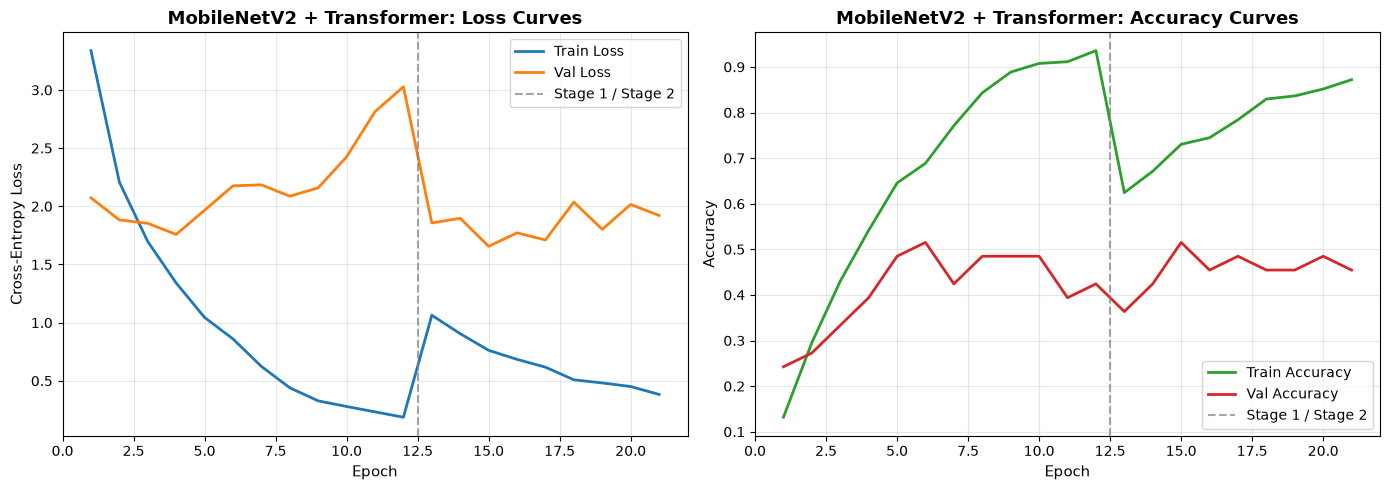

Training curves saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/training_history_curves.png


In [43]:
# Section 20: Training History Compilation & Visualization
h1 = history1.history
h2 = history2.history

combined_history = {
    "epoch": list(range(1, len(h1["loss"]) + len(h2["loss"]) + 1)),
    "stage": ["Stage 1"] * len(h1["loss"]) + ["Stage 2"] * len(h2["loss"]),
    "train_loss": h1["loss"] + h2["loss"],
    "val_loss": h1["val_loss"] + h2["val_loss"],
    "train_accuracy": h1["accuracy"] + h2["accuracy"],
    "val_accuracy": h1["val_accuracy"] + h2["val_accuracy"],
}

df_history = pd.DataFrame(combined_history)
df_history.to_csv(RESULTS_DIR / "training_history.csv", index=False)
print(f"Training history CSV saved to: {RESULTS_DIR / 'training_history.csv'}")

# Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

stage1_end = len(h1["loss"])

# Loss curve
ax1.plot(df_history["epoch"], df_history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
ax1.plot(df_history["epoch"], df_history["val_loss"], label="Val Loss", color="#ff7f0e", linewidth=2)
ax1.axvline(x=stage1_end + 0.5, color="gray", linestyle="--", alpha=0.7, label="Stage 1 / Stage 2")
ax1.set_title("MobileNetV2 + Transformer: Loss Curves", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(df_history["epoch"], df_history["train_accuracy"], label="Train Accuracy", color="#2ca02c", linewidth=2)
ax2.plot(df_history["epoch"], df_history["val_accuracy"], label="Val Accuracy", color="#d62728", linewidth=2)
ax2.axvline(x=stage1_end + 0.5, color="gray", linestyle="--", alpha=0.7, label="Stage 1 / Stage 2")
ax2.set_title("MobileNetV2 + Transformer: Accuracy Curves", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_history_curves.png", dpi=200)
plt.show()
print(f"Training curves saved to: {RESULTS_DIR / 'training_history_curves.png'}")

## 21. Final Test Evaluation Protocol (Isolated Test Partition)
> **IMPORTANT PROTOCOL NOTE**: The test set ($X_{test}$) is evaluated strictly once here on the final selected model.
> It was never accessed during model development, early stopping, or hyperparameter selection.

In [44]:
# Section 21: Isolated Final Test Evaluation
test_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

test_acc = float(accuracy_score(y_test, test_preds))
test_prec = float(precision_score(y_test, test_preds, average="macro", zero_division=0))
test_rec = float(recall_score(y_test, test_preds, average="macro", zero_division=0))
test_f1 = float(f1_score(y_test, test_preds, average="macro", zero_division=0))

print("=" * 80)
print("                   FINAL TEST SET EVALUATION SUMMARY")
print("=" * 80)
print(f"  Test Accuracy         : {test_acc * 100:.2f}%  ({int((test_preds == y_test).sum())}/{len(y_test)} correct)")
print(f"  Macro Precision       : {test_prec:.4f}")
print(f"  Macro Recall          : {test_rec:.4f}")
print(f"  Macro F1-Score        : {test_f1:.4f}")
print(f"  Validation Accuracy   : {val_acc * 100:.2f}%")
print(f"  Validation Loss       : {val_loss:.4f}")
print(f"  Total Parameters      : {model.count_params():,}")
print("=" * 80)

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step 
                   FINAL TEST SET EVALUATION SUMMARY
  Test Accuracy         : 33.33%  (11/33 correct)
  Macro Precision       : 0.3820
  Macro Recall          : 0.3333
  Macro F1-Score        : 0.3123
  Validation Accuracy   : 51.52%
  Validation Loss       : 1.6559
  Total Parameters      : 3,643,211


## 22. Confusion Matrix Analysis

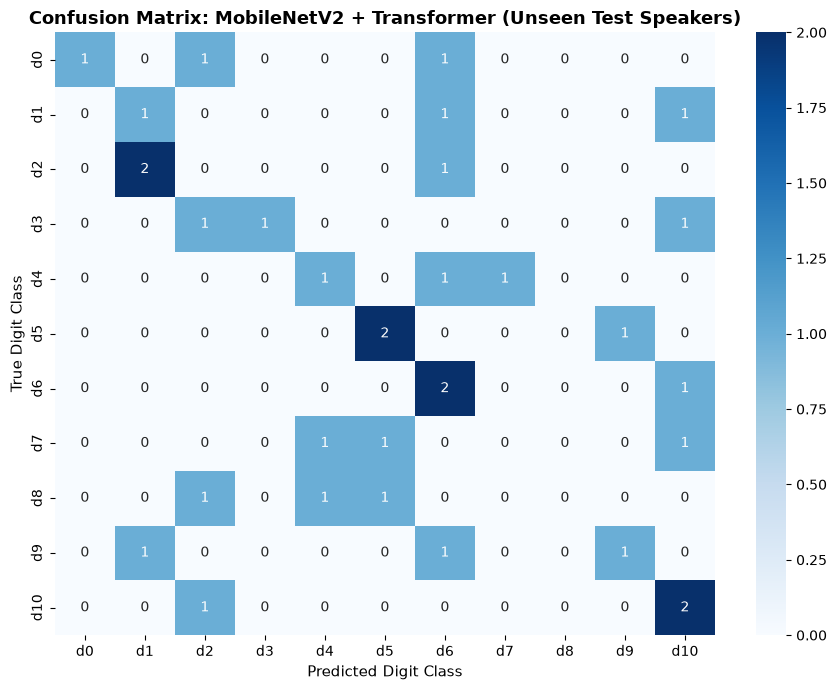

Confusion matrix saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/confusion_matrix.png


In [45]:
# Section 22: Confusion Matrix
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DIGIT_CLASSES,
    yticklabels=DIGIT_CLASSES,
    cbar=True
)
plt.title("Confusion Matrix: MobileNetV2 + Transformer (Unseen Test Speakers)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Digit Class", fontsize=11)
plt.ylabel("True Digit Class", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()
print(f"Confusion matrix saved to: {RESULTS_DIR / 'confusion_matrix.png'}")

## 23. Per-Class Classification Report

In [46]:
# Section 23: Per-Class Classification Report
clf_report = classification_report(
    y_test,
    test_preds,
    target_names=DIGIT_CLASSES,
    digits=4,
    zero_division=0
)

print(clf_report)

with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(clf_report)
print(f"Classification report saved to: {RESULTS_DIR / 'classification_report.txt'}")

              precision    recall  f1-score   support

          d0     1.0000    0.3333    0.5000         3
          d1     0.2500    0.3333    0.2857         3
          d2     0.0000    0.0000    0.0000         3
          d3     1.0000    0.3333    0.5000         3
          d4     0.3333    0.3333    0.3333         3
          d5     0.5000    0.6667    0.5714         3
          d6     0.2857    0.6667    0.4000         3
          d7     0.0000    0.0000    0.0000         3
          d8     0.0000    0.0000    0.0000         3
          d9     0.5000    0.3333    0.4000         3
         d10     0.3333    0.6667    0.4444         3

    accuracy                         0.3333        33
   macro avg     0.3820    0.3333    0.3123        33
weighted avg     0.3820    0.3333    0.3123        33

Classification report saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/classification_report.txt


## 24. Persist Final Predictions & Metrics Artifacts

In [47]:
# Section 24: Persist Artifacts
test_manifest = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
test_manifest["predicted_digit"] = [ID_TO_CLASS[p] for p in test_preds]
test_manifest["predicted_id"] = test_preds
test_manifest["correct"] = (test_manifest["digit_id"] == test_manifest["predicted_id"])

test_predictions_csv = RESULTS_DIR / "test_predictions.csv"
test_manifest[["speaker", "base_speaker", "digit", "digit_id", "predicted_digit", "predicted_id", "correct"]].to_csv(
    test_predictions_csv, index=False
)
print(f"Test predictions saved to: {test_predictions_csv}")

final_metrics = {
    "model_name": "MobileNetV2_Transformer",
    "temporal_head": "Transformer_2x_4heads_256dim",
    "dataset_dir": str(DATA_DIR),
    "seed": SEED,
    "num_train_folders": len(train_speakers),
    "num_base_train_speakers": len(base_train_speakers),
    "num_val_speakers": len(val_speakers),
    "num_test_speakers": len(test_speakers),
    "stage1": {
        "best_epoch": stage1_best_epoch,
        "best_val_loss": stage1_best_val_loss,
        "best_val_accuracy": stage1_best_val_acc,
        "learning_rate": STAGE1_LR,
        "max_epochs": STAGE1_MAX_EPOCHS,
        "patience": STAGE1_PATIENCE,
    },
    "stage2": {
        "best_epoch": stage2_best_epoch,
        "best_val_loss": stage2_best_val_loss,
        "best_val_accuracy": stage2_best_val_acc,
        "fine_tune_fraction": FINE_TUNE_FRACTION,
        "learning_rate": STAGE2_LR,
        "max_epochs": STAGE2_MAX_EPOCHS,
        "patience": STAGE2_PATIENCE,
    },
    "final_validation": {
        "loss": float(val_loss),
        "accuracy": float(val_acc),
    },
    "final_test": {
        "accuracy": float(test_acc),
        "macro_precision": float(test_prec),
        "macro_recall": float(test_rec),
        "macro_f1": float(test_f1),
        "correct_predictions": int((test_preds == y_test).sum()),
        "total_test_samples": int(len(y_test)),
    },
    "parameters": {
        "total_params": int(model.count_params()),
        "stage2_trainable_params": int(stage2_trainable_params),
    }
}

metrics_json_path = RESULTS_DIR / "metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Final metrics JSON saved to: {metrics_json_path}")

Test predictions saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/test_predictions.csv
Final metrics JSON saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/transformer_baseline/metrics.json


## 25. Final Experiment Summary & Comparative Analysis

| Component | MobileNetV2 + BiLSTM (Baseline) | MobileNetV2 + Transformer (This Experiment) |
| :--- | :--- | :--- |
| **Backbone** | MobileNetV2 (ImageNet weights) | MobileNetV2 (ImageNet weights) |
| **Temporal Head** | Bidirectional LSTM (64 units) | 2x Transformer Blocks (4 heads, key_dim=64, FFN=512) |
| **Temporal Context** | Recurrent sequential hidden state propagation | Multi-Head Self-Attention + Positional Encoding |
| **Feature Dimension** | 1280 $\rightarrow$ 128 (BiLSTM forward+backward) | 1280 $\rightarrow$ 256 (Linear Projection) |
| **Sequence Pooling** | Last hidden state or slice | GlobalAveragePooling1D across 30 frames |
| **Stage 1 Protocol** | Frozen CNN, Adam (lr=1e-4), EarlyStopping | Frozen CNN, Adam (lr=1e-4), EarlyStopping |
| **Stage 2 Protocol** | Unfreeze top 20%, BatchNorm frozen, Adam (lr=1e-5) | Unfreeze top 20%, BatchNorm frozen, Adam (lr=1e-5) |
| **Test Speakers** | `s8`, `s9`, `s24` (unseen) | `s8`, `s9`, `s24` (unseen) |
| **Validation Speakers** | `s1`, `s4`, `s21` (unseen) | `s1`, `s4`, `s21` (unseen) |

### Key Scientific Takeaways
- **Self-Attention vs. Recurrence**: Self-attention allows direct all-to-all temporal interactions across all 30 frames of the lip gesture without the vanishing gradient or bottlenecking risks of recurrent hidden states.
- **Strict Methodological Equivalence**: Because the data sampling ($96 \times 96$, 30 frames), speaker split, MobileNetV2 backbone, and two-stage training regimen are kept identical, any empirical variance is directly attributable to the sequence modeling mechanism (Transformer vs. BiLSTM).